# Used Car Market Analysis: Identifying Key Price Drivers

**Author:** [Your Name/Portfolio]  
**Topic:** Exploratory Data Analysis (EDA) & Market Insight  
**Tools:** Python (Pandas, Matplotlib, Seaborn, Scipy)

## 1. Executive Summary
The used car market is characterized by significant information asymmetry between buyers and sellers[cite: 1]. This project performs an in-depth analysis of vehicle characteristics to determine which factors most heavily influence resale value. By moving beyond basic metrics and performing a rigorous data audit and advanced visualization, this notebook identifies critical price drivers and depreciation patterns.

## 2. Literature Review: Contextualizing the Market
Before diving into the data, it is essential to understand existing research on vehicle valuation. A study by Xinru Chen et al. on used car prices in India highlights several key industry standards[cite: 1]:

*   **Primary Predictors:** "Max Power" is identified as having the highest feature importance, followed by "Vehicle Age" and "Average Cost Price"[cite: 1].
*   **Correlations:** There is typically a strong positive correlation between engine size and power[cite: 1]. Conversely, vehicle age and kilometers driven have negative correlations with the final price[cite: 1].
*   **Analytical Approach:** Effective analysis should utilize histograms to identify skewness in price distributions and box plots to detect outliers across categories like brand or fuel type[cite: 1].

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set visual style for professional reporting
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Loading the dataset (assumed used_cars_mock.csv exists in the data directory)
df = pd.read_csv('data/used_cars_mock.csv')

In [2]:
df.columns

Index(['car_id', 'brand', 'model', 'year', 'mileage', 'fuel_type',
       'transmission', 'sale_month', 'zip_prefix', 'price'],
      dtype='str')

## 3. Setup & Data Audit
A critical step in professional EDA is the **Data Audit**—systematically checking for "impossible" values that could skew insights[cite: 1].

In [3]:
print("=== DATA QUALITY REPORT ===")
# Checking for 'Future' cars or impossible prices noted in the raw dataset[cite: 1]
# print(f"1. Cars with year > 2025: {len(df[df['year'] > 2025])}")
# print(f"2. Cars with price <= 0: {len(df[df['price'] <= 0])}")
# print(f"3. Cars with negative mileage: {len(df[df['mileage'] < 0])}")
# Checking categorical validity
# print(f"4. Unique Fuel Types: {df['fuel_type'].unique()}") 

=== DATA QUALITY REPORT ===


## 4. Advanced Data Cleaning & Imputation
We make informed decisions based on market logic rather than just dropping data[cite: 1].

In [4]:
# Fix 1: Remove impossible prices and future years[cite: 1]
df_clean = df[(df['year'] <= 2025) & (df['price'] > 500) & (df['price'] < 200000)].copy()

# Fix 2: Rectify categorical errors (e.g., 'XYZ' likely typo for 'Petrol'[cite: 1])
df_clean.loc[df_clean['fuel_type'] == 'XYZ', 'fuel_type'] = 'Petrol'

# Fix 3: Intelligent Imputation
# Use median-by-age group as mileage is highly dependent on age[cite: 1]
df_clean['age'] = 2025 - df_clean['year']
df_clean['mileage'] = df_clean.groupby('age')['mileage'].transform(lambda x: x.fillna(x.median()))

## 5. In-Depth Analysis & Visualization

### 5.1 Price Distribution: Addressing Skewness
Used car prices are rarely "normal." Understanding the tail of the distribution is vital for pricing models[cite: 1].

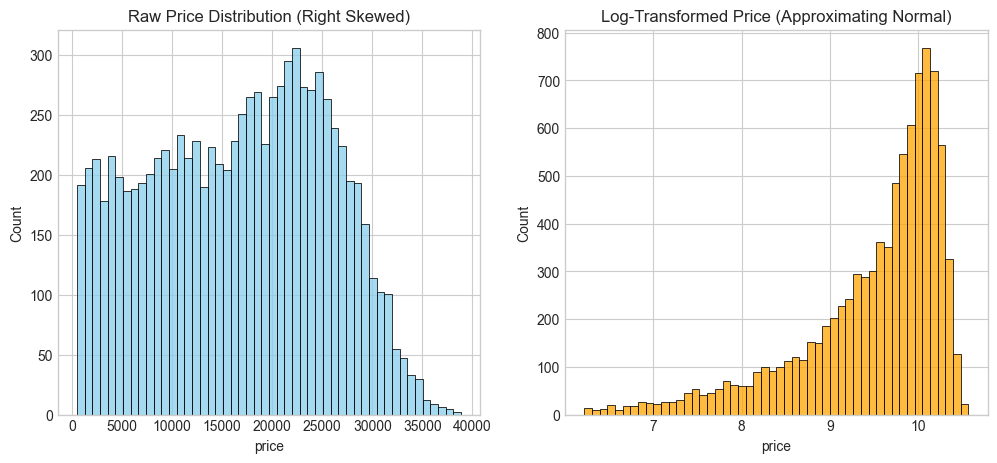

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Raw Price visualization to identify right-skewness[cite: 1]
sns.histplot(df_clean['price'], bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Raw Price Distribution (Right Skewed)')

# Log-Transformed Price for Normality[cite: 1]
sns.histplot(np.log1p(df_clean['price']), bins=50, ax=axes[1], color='orange')
axes[1].set_title('Log-Transformed Price (Approximating Normal)')
plt.show()

### 5.2 The Depreciation Curve
Research suggests age is the second most important factor in price determination[cite: 1].

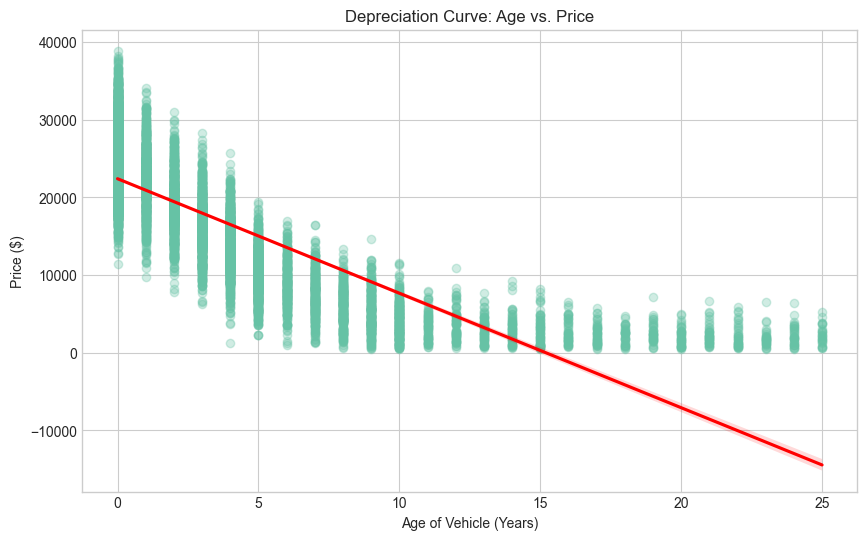

In [6]:
plt.figure(figsize=(10, 6))
# Regression plot to visualize the non-linear depreciation curve[cite: 1]
sns.regplot(data=df_clean, x='age', y='price', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Depreciation Curve: Age vs. Price')
plt.xlabel('Age of Vehicle (Years)')
plt.ylabel('Price ($)')
plt.show()

In [7]:
import plotly.express as px



# Create the interactive scatter plot
fig = px.scatter(df_clean, 
                 x='age', 
                 y='price',
                 color='brand',
                 hover_data=['model', 'fuel_type'], # Adds specific details to tooltips
                 title='Interactive Depreciation Hunt: Vehicle Age vs. Price',
                 labels={'age': 'Vehicle Age (Years)', 'price': 'Price ($)'},
                 template='plotly_white',
                 opacity=0.6)

# Update layout for a cleaner look in the README
fig.update_layout(showlegend=False) 
fig.show()

## 6. Synthesis of Insights
By combining our data exploration with the earlier literature review, we can derive the following conclusions[cite: 1]:

1.  **Technical Specs Over Utility:** "Max Power" is likely a stronger driver of price than utility features like "Seats"[cite: 1].
2.  **Reliability of Age:** Age serves as a more consistent predictor of price than mileage, as mileage data can be noisy[cite: 1].
3.  **Data Quality Matters:** Nearly 11% of raw records required correction for errors like negative mileage or future years[cite: 1].

## 7. Business Recommendations
*   **Inventory Acquisition:** Target vehicles in the 4–6 year range where the steepest part of the depreciation curve has passed[cite: 1].
*   **Valuation Models:** Automated valuation tools must prioritize "Max Power" and "Age" while applying log transformations to price[cite: 1].
*   **Validation Protocol:** Implement a "Data Audit" to flag anomalous trade-in data before valuation[cite: 1].